# Epidemic Spreading in Hyperbolic Space (ES-HS)
TFG Adrià Rojo, 2026

## Compilar eines

In [7]:
! mkdir tools -p

### SD Model

In [1]:
! g++ -O3 -std=c++17 -lboost_system -lboost_math_c99 SD-model/src/generatingSD_unix.cpp -o tools/genSD

In file included from /usr/include/boost/math/quadrature/gauss.hpp:15,
                 from SD-model/src/../include/generatingSD.hpp:41,
                 from SD-model/src/../include/generatingSD_unix.hpp:33,
                 from SD-model/src/generatingSD_unix.cpp:30:
/usr/include/boost/math/special_functions/legendre.hpp: In instantiation of ‘std::pair<_FIter, _FIter> boost::math::detail::legendre_p_zero_func<T, Policy>::operator()(T) const [with T = double; Policy = boost::math::policies::policy<boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy>]’:
/usr/include/boost/math/tools/roots.hpp:259:29:   required from

### Mercator

In [14]:
! g++ -O3 -std=c++11 -fpermissive -I ./mercator/include/ ./mercator/src/embeddingS1_unix.cpp -o ./tools/mercator


En el fichero incluido desde ./mercator/src/../include/Eigen/Core:467,
                 desde ./mercator/src/../include/embeddingS1.hpp:52,
                 desde ./mercator/src/../include/embeddingS1_unix.hpp:36,
                 desde ./mercator/src/embeddingS1_unix.cpp:30:
./mercator/src/../include/Eigen/src/Core/Transpositions.h: In function ‘const Eigen::Product<OtherDerived, Eigen::Transpose<Eigen::TranspositionsBase<Derived> >, 2> Eigen::operator*(const MatrixBase<OtherDerived>&, const Transpose<TranspositionsBase<Derived> >&)’:
./mercator/src/../include/Eigen/src/Core/Transpositions.h:387:87: aviso: ‘const class Eigen::Transpose<Eigen::TranspositionsBase<Derived> >’ has no member named ‘derived’ []8;;https://gcc.gnu.org/onlinedocs/gcc-15.2.0/gcc/C_002b_002b-Dialect-Options.html#index-Wno-template-body-Wtemplate-body]8;;]
  387 | Derived, Transpose, AliasFreeProduct>(matrix.derived(), trt.derived());
      |                                                             ^~~~~~~

### Epidemics

In [32]:
! gfortran -O3 -march=native -funroll-loops -fopenmp -g \
    ./epidemics-tfg/include/mt19937.f90 ./epidemics-tfg/include/mt19937_par.f90 ./epidemics-tfg/include/fhash.f90 \
    ./epidemics-tfg/include/net_loader.f90 ./epidemics-tfg/include/reversed_skiplist.f90 ./epidemics-tfg/include/epidemic.f90 \
    ./epidemics-tfg/main2.f90 \
    -o ./tools/epidemics
! rm ./*.mod

In [9]:
! ./tools/epidemics -h

SIMULADOR DE EPIDEMIAS EN REDES
Adrià Rojo

Uso: programa [OPCIONES] ARCHIVO_RED

ARGUMENTOS OBLIGATORIOS:
  ARCHIVO_RED                    Archivo de la red (formato compatible con net_loader)

OPCIONES:
  -h, --help                     Muestra esta ayuda

  -i, --infection-rate VALOR     Tasa de infección (obligatorio)
  -r, --recovery-rate VALOR      Tasa de recuperación (obligatorio)
  -m, --model {SIR,SIS}          Modelo epidémico (obligatorio)

  -lt, --limit-time VALOR        Tiempo máximo de simulación (default: 50.0)
  -s, --seed VALOR               Semilla para el generador aleatorio
  -sn, --start-node              Indica el nodo inicial para infectar
                                 (default: el nodo con degree más alto)
  -w, --weighted                 Indica que la red es ponderada
  -b, --batch-file ARCHIVO       Archivo con lista de simulaciones a ejecutar
                                 (cada línea: inf_rate rec_rate seed limit_time model [start_node])

ARCHIVOS DE S

## Generació de xarxes

In [10]:
! ./tools/genSD -h


NAME
  generatingSD -- a program to generate complex networks in the S^D metric space

SYNOPSIS
  generatingSD [options]
  

The following options are available:
  -b [BETA]        Specifies the value for parameter beta.
  -d [DIMENSION]   Specifies model's dimension (S^D).
  -g [GAMMA]       Exponent of the power-law distribution for hidden degrees.
  -n [SIZE]        Network size.
  -k [MEAN_DEGREE] Mean degree of nodes.
  -l [KAPPAS]      File consisting of the hidden degrees 
  -s [SEED]        Program uses a custom seed for the random number generator. Default: EPOCH.
  -v               Outputs the hidden variables (kappa and nodes'positions) used to the generate the network into a file (uses the edgelist's rootname).
  -h               Print this message on screen and exit.
  -o [FILENAME]    Name of the output file (without extension) (default: net)
  


In [133]:
! ./tools/mercator -h

./tools/mercator: invalid option -- 'h'

NAME
	Mercator: Inference of high-quality embeddings of complex networks into the
	          hyperbolic disk

SYNOPSIS
	mercator [options] <edgelist_filename>

INPUT
	The structure of the graph is provided by a text file containing it edgelist. Each
	line in the file corresponds to an edge in the graph (i.e., [VERTEX1] [VERTEX2]).
	  - The name of the vertices need not be integers (they are stored as std::string).
	  - Directed graphs will be converted to undirected.
	  - Multiple edges, self-loops and weights will be ignored.
	  - Lines starting with '# ' are ignored (i.e., comments).


The following options are available:
	-a             Screen mode. Program outputs details about its progress on screen
	               (through std::clog) instead of in a log file. Useful to gather all
	               output in a single file if mercator is a subroutine of a script.
	-b [VALUE]     Specify the value for beta to be used for the embedding. By 
	   

In [3]:
! ./tools/genSD -d 1 -n 10000 -g 1.729 -k 11.53 -b 3 -s 12345 -o pipeline-output-s1h2/n10000

OUTPUT_ROOTNAME = /home/adria/universitat/epidemics-tfg-pipeline/pipeline-output-s1h2/n10000
edgelist_file = /home/adria/universitat/epidemics-tfg-pipeline/pipeline-output-s1h2/n10000.edge


In [1]:
! ./tools/mercator -o pipeline-output-s1h2/n10000 -b 3 -s 12345 ./pipeline-output-s1h2/n10000.edge

In [ ]:
! ./tools/mercator -o pipeline-output/ -s 12345 ./airports.edges
! ./tools/mercator -o pipeline-output/ -s 12345 ./airports_GC.edge


More than one component found (3304/3330) vertices in the largest component.
Edges belonging to the largest component saved to ./airports_GC.edge. Please rerun the program using this new edgelist.

terminate called without an active exception


## Visualització

In [56]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Configuración estilo revtex4
plt.style.use('default')  # Empezar desde cero

params = {
    # Fuentes
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Computer Modern Roman'],
    'font.size': 10,
    'font.weight': 'normal',
    
    # Tamaño de figura (ancho de columna típico de revtex4: ~3.5 pulgadas)
    'figure.figsize': (3.5, 2.8),
    'figure.dpi': 100,
    'figure.facecolor': 'white',
    
    # Ejes
    'axes.labelsize': 10,
    'axes.labelweight': 'normal',
    'axes.linewidth': 0.8,
    'axes.edgecolor': 'black',
    'axes.facecolor': 'white',
    
    # Ticks
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.size': 2,
    'ytick.minor.size': 2,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    
    # Líneas
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    
    # Leyenda
    'legend.fontsize': 9,
    'legend.frameon': False,
    'legend.loc': 'best',
    
    # Guardado
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,

    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath}',
    'pgf.texsystem': 'xelatex'
}

In [2]:
# arxiv 1v41801.4091

def kappa_to_hyperbolic(kappa, kappa_min): # ln k/k_0
    """
    Convierte κ a coordenada radial hiperbólica
    r = ln(κ/κ_min)
    """
    return np.log(kappa / kappa_min)

def hyperbolic_to_mercator(r_hiperbolico, edge_count, mu, kappa_min):
    """
    Convierte radio hiperbólico a coordenada en disco de Poincaré
    r_poincare = R*-2*r_hyp
    """
    R = 2 * np.log(edge_count/(mu*np.pi*kappa_min**2))
    return R - 2* r_hiperbolico

kappa_to_hyperbolic = np.vectorize(kappa_to_hyperbolic, excluded={1, 'kappa_min'})
hyperbolic_to_mercator = np.vectorize(hyperbolic_to_mercator, excluded={1, 'edge_count', 2, 'mu', 3, 'kappa_min'})

def mercator_to_poincare(r_mercator, R):
    """
    Convierte coordenada radial en proyección Mercator a radio en disco de Poincaré.
    """
    r_hip = (R - r_mercator) / 2.0
    # r_hip puede ser negativo si r_mercator > R; pero en teoría nunca ocurre.
    # Aseguramos que r_hip >= 0 (clipping)
    r_hip = max(r_hip, 0.0)
    return np.tanh(r_hip / 2.0)

def poincare_to_mercator(r_poincare, R):
    """
    Convierte radio en disco de Poincaré (0 a 1) a coordenada Mercator.
    """
    if r_poincare >= 1.0:
        r_poincare = 1.0 - 1e-12
    r_hip = 2.0 * np.arctanh(r_poincare)
    r_mercator = R - 2.0 * r_hip
    return r_mercator

def mercator_disc(data: pd.DataFrame, mark_nodes: list[str] = [], net: nx.Graph = None, title: str = None):
    fig, ax = plt.subplots(1, 1, figsize=(14, 12), dpi=100)
    kappa_vals = []
    positions = {v: (x, y) for _, (v, x, y) in data[['Vertex', 'Disc.X', 'Disc.Y']].iterrows()}
        
    kappa_vals = np.log10(data['Inf.Kappa'])
    
    if (net):
        for a, b in net.edges():
            xa, ya = positions[a]
            xb, yb = positions[b]
            ax.add_line(plt.Line2D([xa, xb], [ya, yb], linewidth=0.05, color='#00000015'))
    x_orig, y_orig = zip(*positions.values())
    max_val = np.max(np.abs([*x_orig, *y_orig]))*1.1
    scatter = ax.scatter(x_orig, y_orig, c=kappa_vals, cmap='viridis', zorder=10000,
                        s=15, alpha=0.5, edgecolors='black', linewidth=0.3, vmin=-1, vmax=1)
    # circle = plt.Circle((0, 0), 1, fill=False, color='red', linestyle='--')
    # ax.add_patch(circle)
    
    for mark_node in mark_nodes:
        mark_data = data[data['Vertex'] == mark_node].iloc[0]
        ax.plot(mark_data['Disc.X'], mark_data['Disc.Y'], 'r*', markersize=15, markeredgecolor='black')

    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend()
    if (title):
        ax.set_title(title)
    plt.colorbar(scatter, ax=ax, label='log10(κ)')
    plt.show()
    plt.close(fig)

def read_hyperbolic_data(archivo_coords, archivo_edges):
    """
    Lee el grafo y las coordenadas hiperbólicas del formato S1/H2
    """
    # Leer grafo
    G = nx.read_edgelist(archivo_edges)
    
    # Leer coordenadas
    df = pd.read_csv(archivo_coords, sep='\\s+', comment='#', 
                     names=["Vertex", "Inf.Kappa", "Inf.Theta", "Inf.Hyp.Rad."])
    
    # Convertir Vertex a string
    df['Vertex'] = df['Vertex'].astype(str)
    # df = df.set_index('Vertex')
    # Leer parámetros del archivo
    params = {}
    with open(archivo_coords, 'r') as f:
        for line in f:
            if line.startswith('#') and ':' in line:
                parts = line.strip('# ').split(':')
                if len(parts) == 2:
                    key = parts[0].strip()
                    if (key.startswith('-')):
                        key = key[1:].strip()
                    try:
                        params[key] = float(parts[1].strip())
                    except ValueError:
                        params[key] = parts[1].strip()
    
    df['Disc.Radius'] = hyperbolic_to_mercator(kappa_to_hyperbolic(df['Inf.Kappa'], params['kappa_min']), params['nb. vertices'], params['mu'], params['kappa_min'])

    df['Disc.X'] = df['Disc.Radius']*np.cos(df['Inf.Theta'])
    df['Disc.Y'] = df['Disc.Radius']*np.sin(df['Inf.Theta'])
    df['Poincare.Radius'] = df['Disc.Radius']/len(df['Disc.Radius'])*2*np.pi
    df['Poincare.X'] = df['Poincare.Radius']*np.cos(df['Inf.Theta'])
    df['Poincare.Y'] = df['Poincare.Radius']*np.sin(df['Inf.Theta'])
    # df['Hyp.X0'] = np.cosh(df['Disc.Radius'])
    # df['Hyp.X1'] = np.sinh(df['Disc.Radius'])*np.cosh(df['Inf.Theta'])
    # df['Hyp.X2'] = np.sinh(df['Disc.Radius'])*np.sinh(df['Inf.Theta'])

    return G, df, params

def mercator_epidemic_disc(data: pd.DataFrame, susceptible_coords, infected_coords, recovered_coords, filename: str = None, time:str = None):
    fig, ax = plt.subplots(1, 1, figsize=(14, 12), dpi=100)
    x_orig_white, y_orig_white = [], []
    x_orig_pink, y_orig_pink = [], []
    x_orig_red, y_orig_red = [], [] 
    if len(infected_coords) > 0:
        x_orig_red, y_orig_red = zip(*infected_coords) 
    if (len(recovered_coords)):
        x_orig_pink, y_orig_pink = zip(*recovered_coords)
    if len(susceptible_coords) > 0:
        x_orig_white, y_orig_white = zip(*susceptible_coords)

    max_val = np.max(np.abs([*data['Disc.X'], *data['Disc.Y']]))*1.1

    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    ax.scatter(x_orig_white, y_orig_white, s=15, alpha=0.5, linewidth=0.3, c='white', edgecolors='black')
    ax.scatter(x_orig_pink, y_orig_pink, alpha=0.1, s=15, c='red')
    ax.scatter(x_orig_red, y_orig_red, s=15, c='red')
    
    ax.set_aspect('equal')
    if (time is not None):
        ax.set_title(f"t={time:.03f}")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    if (filename):
        fig.savefig(filename)
    else:
        plt.show()
    fig.clf()
    plt.close(fig)

        


### Mapa

In [3]:
coords_file = "./pipeline-output-s1h2/n10000.inf_coord"
edges_file = "./pipeline-output-s1h2/n10000.edge"
# Leer datos
G, df, params = read_hyperbolic_data(coords_file, edges_file)

df

,Vertex,Inf.Kappa,Inf.Theta,Inf.Hyp.Rad.,Disc.Radius,Disc.X,Disc.Y,Poincare.Radius,Poincare.X,Poincare.Y
0,0,1.364240,3.86490,32.7133,32.713342,-24.522602,-21.651899,0.020598,-0.015440,-0.013633
1,1,14.976800,5.16863,27.9215,27.921532,12.301577,-25.065577,0.017581,0.007746,-0.015782
2,2,133.101000,4.76061,23.5523,23.552320,1.135277,-23.524943,0.014830,0.000715,-0.014812
3,3,0.846688,3.46449,33.6674,33.667383,-31.927453,-10.683182,0.021198,-0.020103,-0.006727
4,4,1.735580,1.52175,32.2318,32.231853,1.580220,32.193093,0.020294,0.000995,0.020270
...,...,...,...,...,...,...,...,...,...,...
9974,9995,219.915000,2.84039,22.5480,22.548054,-21.532950,6.689307,0.014197,-0.013558,0.004212
9975,9996,2.535420,2.27340,31.4738,31.473818,-20.338598,24.019630,0.019817,-0.012806,0.015124
9976,9997,3.915890,3.42045,30.6044,30.604451,-29.422219,-8.424099,0.019270,-0.018525,-0.005304
9977,9998,6.988970,5.52294,29.4459,29.445870,21.338450,-20.291126,0.018540,0.013436,-0.012776


In [5]:
max(dict(G.degree()).items(), key=lambda x: x[1])

('996', 9238)

In [4]:
df[df['Vertex'] == '996']

,Vertex,Inf.Kappa,Inf.Theta,Inf.Hyp.Rad.,Disc.Radius,Disc.X,Disc.Y,Poincare.Radius,Poincare.X,Poincare.Y
996,996,193838.0,2.60967,8.98497,8.98498,-7.743557,4.557104,0.005657,-0.004876,0.002869


/tmp/ipykernel_83310/1079217258.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


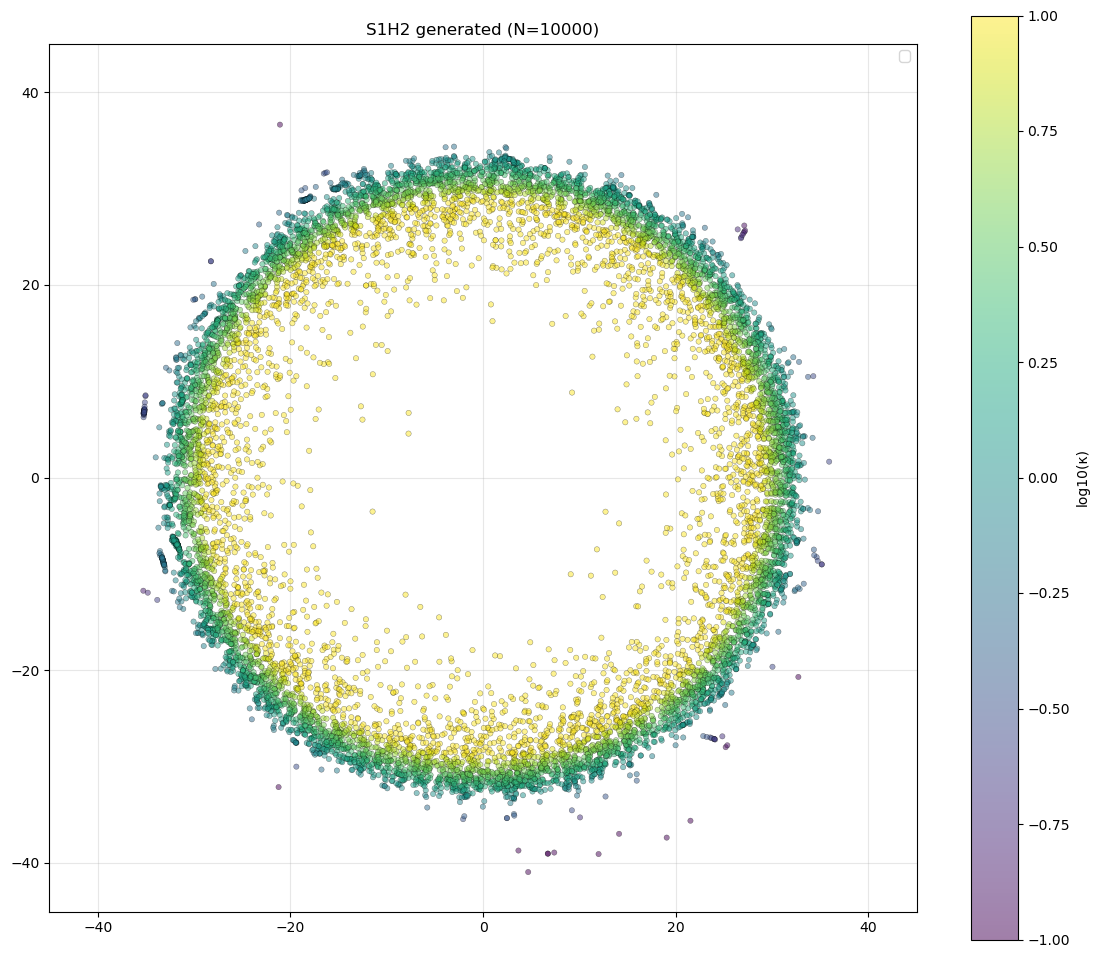

In [5]:
mercator_disc(df, title='S1H2 generated (N=10000)')

### Rotació 

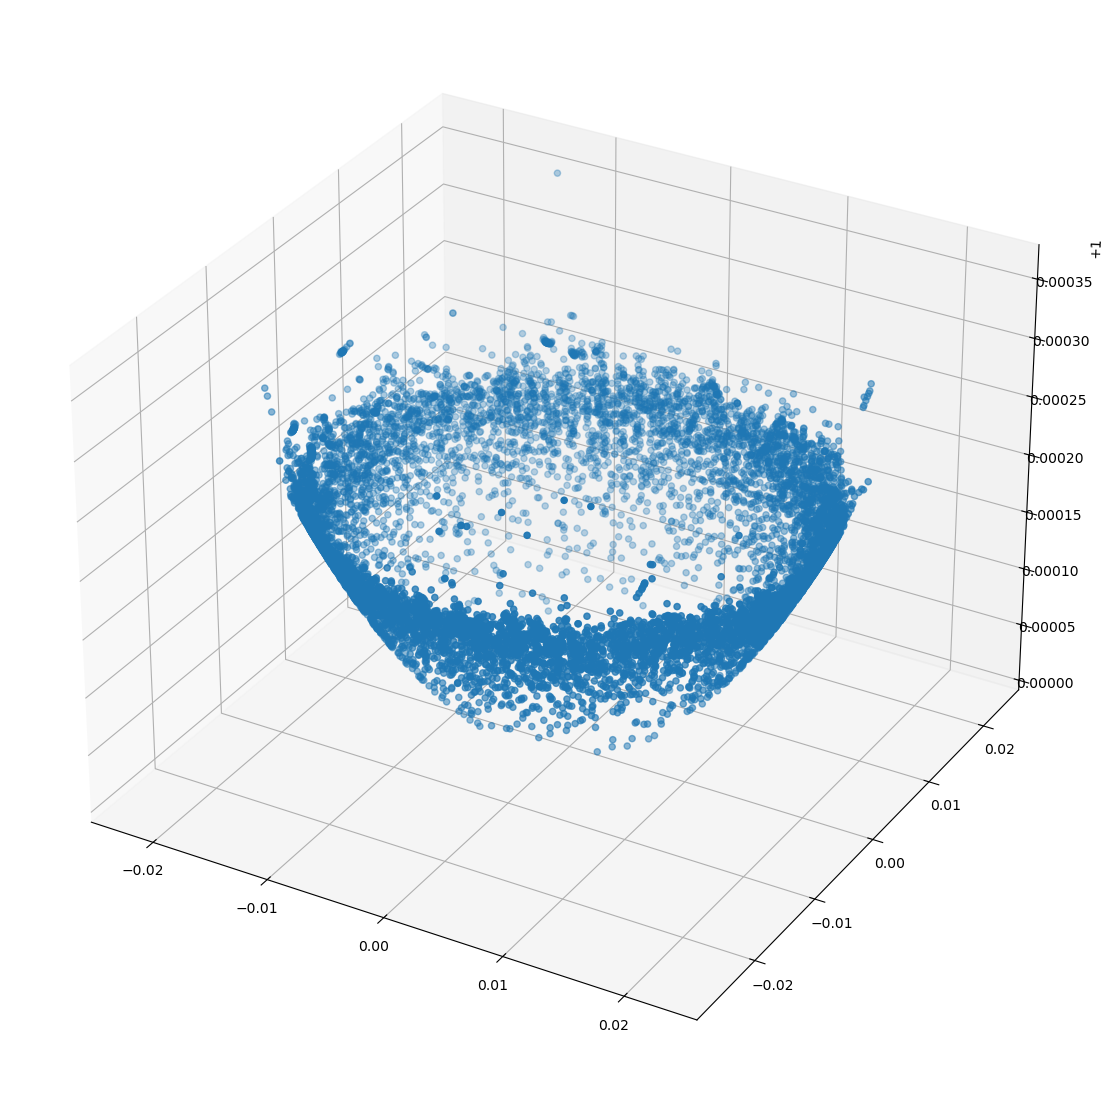

In [54]:
fig = plt.figure(dpi=100, figsize=(14, 14))
ax = fig.add_subplot(projection='3d')
# df_l = df.iloc[:500]
R = df['Poincare.Radius']
Xs, Ys = R*np.cos(df['Inf.Theta']), R*np.sin(df['Inf.Theta'])
ax.scatter(Xs, Ys, np.sqrt(1+Xs**2+Ys**2))


plt.show()

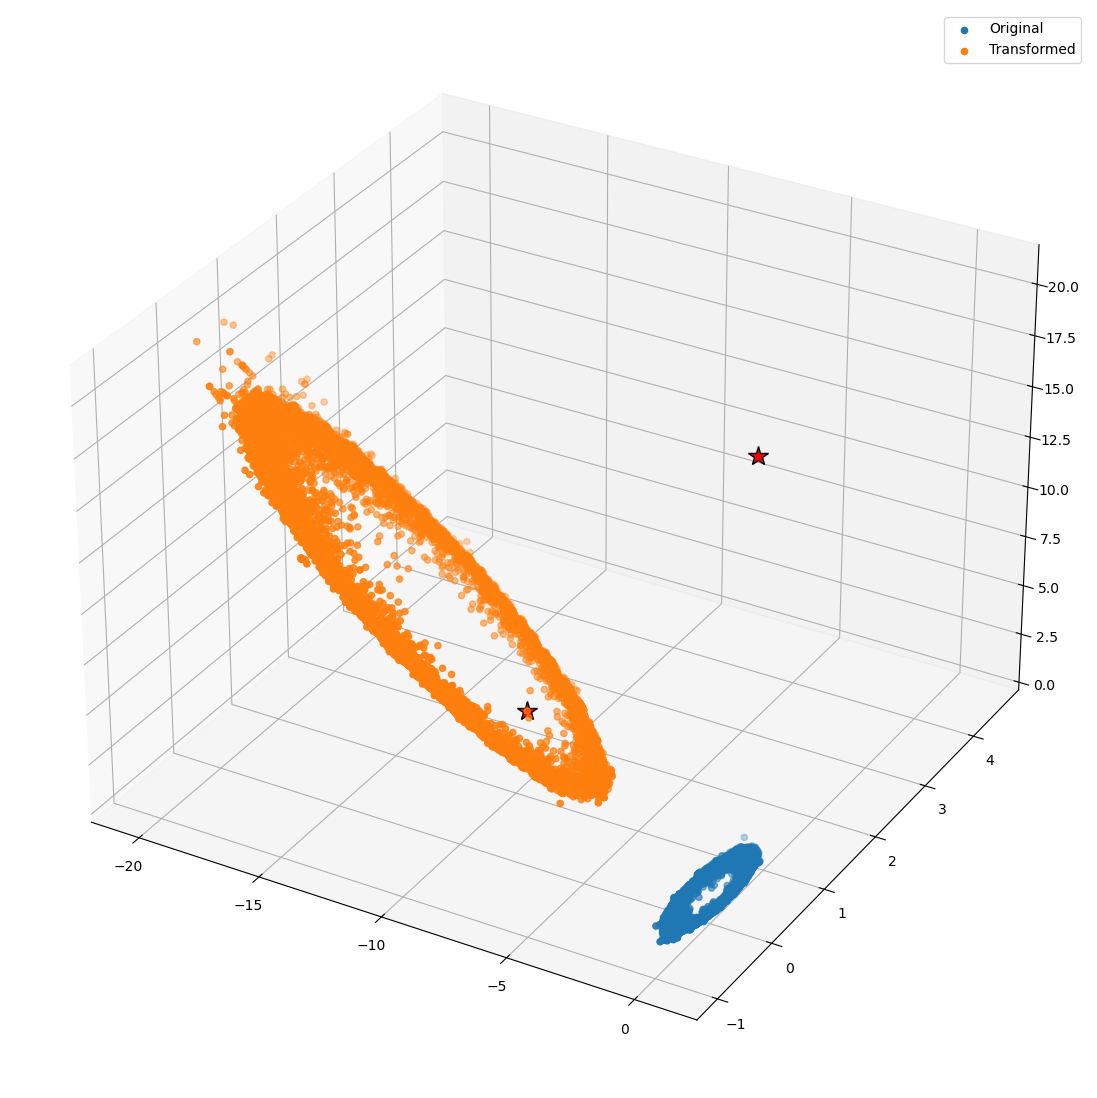

In [ ]:
df_new = df.copy()
R = df['Disc.Radius']/max(df['Disc.Radius'])

X, Y, Z = R*np.cos(df['Inf.Theta']), R*np.sin(df['Inf.Theta'])
disc_center = df[df['Vertex'] == '996'].iloc[0]
x0, y0 = disc_center['Disc.X'], disc_center['Disc.Y']
z0 = np.sqrt(1+x0**2+y0**2)
r = np.sqrt(x0**2+y0**2)
cos_theta = x0 / r
sin_theta = y0 / r
R = np.array([
    [cos_theta, sin_theta, 0],
    [-sin_theta, cos_theta, 0],
    [0, 0, 1]
])
B = np.array([
    [z0, 0, -r],
    [0, 1, 0],
    [-r, 0, z0]
])
L = B @ R
points = np.vstack((X, Y, Z)).T  # forma (N,3)
points_trans = points @ L.T      # cada punto como fila, multiplicar por L^T
df_new['Disc.X'] = points_trans[:, 0]
df_new['Disc.Y'] = points_trans[:, 1]

fig = plt.figure(dpi=100, figsize=(14, 14))
ax = fig.add_subplot(projection='3d')
# ax.view_init(elev=90, azim=-90, roll=0)
# df_l = df.iloc[:500]
ax.scatter(X, Y, np.sqrt(1+X**2+Y**2), label='Original')
ax.scatter(df_new['Disc.X'], df_new['Disc.Y'], np.sqrt(1+df_new['Disc.X']**2+df_new['Disc.Y']**2), label='Transformed')
ax.plot([x0], [y0], [z0], 'r*', markersize=15, markeredgecolor='black')
disc_center = df_new[df_new['Vertex'] == '996'].iloc[0]
x0, y0 = disc_center['Disc.X'], disc_center['Disc.Y']
z0 = np.sqrt(1+x0**2+y0**2)
ax.plot([x0], [y0], [z0], 'r*', markersize=15, markeredgecolor='black')
ax.legend()

plt.show()

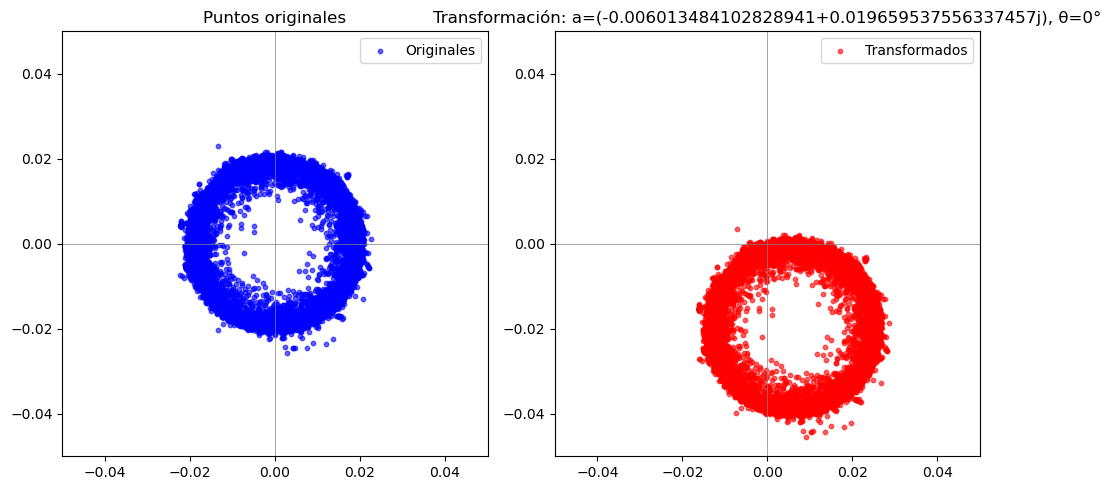

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

class PoincareTransform:
    """
    Transformación de Möbius que preserva el disco unitario:
        f(z) = e^{iθ} * (z - a) / (1 - conj(a) * z)
    con |a| < 1 y θ ∈ ℝ.
    """
    def __init__(self, a, theta=0.0):
        """
        a : número complejo con |a| < 1 (centro de traslación)
        theta : ángulo de rotación en radianes (por defecto 0)
        """
        if np.abs(a) >= 1:
            raise ValueError("|a| debe ser menor que 1 para estar dentro del disco.")
        self.a = complex(a)
        self.theta = theta

    def apply(self, z):
        """
        Aplica la transformación a uno o varios puntos z.
        z puede ser un número complejo o un array de complejos.
        """
        z = np.asarray(z, dtype=np.complex128)
        # Evitar división por cero (si 1 - conj(a)*z = 0, el punto se va al infinito, fuera del disco)
        denom = 1.0 - np.conj(self.a) * z
        # Si denom es cero, el resultado no está en el disco; devolvemos NaN.
        with np.errstate(divide='ignore', invalid='ignore'):
            fz = (z - self.a) / denom
        # Aplicar rotación global
        fz = np.exp(1j * self.theta) * fz
        return fz

    def compose(self, other):
        """
        Composicion de dos transformaciones: self ∘ other.
        Devuelve una nueva transformación que equivale a aplicar other y luego self.
        """
        # Fórmulas para composición: si f1(z) = e^{iθ1} (z - a1)/(1 - a1̄ z)
        # y f2(z) = e^{iθ2} (z - a2)/(1 - a2̄ z),
        # entonces f1(f2(z)) = e^{i(θ1+θ2)} (z - a3)/(1 - a3̄ z)
        # con a3 = (a1 + e^{-iθ1} a2) / (1 + a1̄ e^{-iθ1} a2)  [adaptado de propiedades de SU(1,1)]
        # Implementación simplificada: mejor usar multiplicación de matrices en SU(1,1),
        # pero para este ejemplo aplicamos secuencialmente.
        # Dado que la composición es exacta, podemos crear una nueva transformación
        # calculando el nuevo a y theta.
        # Calculamos los parámetros de la composición:
        # Representación matricial: f(z) = (α z + β) / (β̄ z + ᾱ) con α = e^{iθ/2}, β = -e^{iθ/2} a.
        # Luego la composición corresponde a multiplicar matrices.
        # Para no complicar, aquí aplicamos la composición mediante la función apply
        # y devolvemos un objeto que representa la transformación compuesta mediante los parámetros resultantes.
        # Pero como no tenemos forma directa de extraer a y theta de la composición sin cálculos, 
        # mejor definimos un método que devuelva una nueva transformación con los parámetros compuestos.
        # Implementamos la multiplicación de matrices.
        # Matriz asociada: M = [[α, β], [β̄, ᾱ]] con α = e^{iθ/2}, β = -e^{iθ/2} a.
        # Entonces la transformación es f(z) = (α z + β) / (β̄ z + ᾱ).
        # Para la composición, multiplicamos matrices: M_total = M1 @ M2.
        # Luego extraemos α_total y β_total.

        # Parámetros de self
        θ1 = self.theta
        a1 = self.a
        α1 = np.exp(1j * θ1 / 2)
        β1 = -α1 * a1

        # Parámetros de other
        θ2 = other.theta
        a2 = other.a
        α2 = np.exp(1j * θ2 / 2)
        β2 = -α2 * a2

        # Multiplicación de matrices: [[α1, β1], [β1̄, α1̄]] @ [[α2, β2], [β2̄, α2̄]]
        α_total = α1 * α2 + β1 * np.conj(β2)
        β_total = α1 * β2 + β1 * np.conj(α2)

        # Recuperar a y θ de la matriz resultante:
        # α = e^{iθ/2} / algo? En realidad para que la matriz esté en SU(1,1) debe cumplir |α|^2 - |β|^2 = 1.
        # La matriz resultante ya está en SU(1,1) salvo fase. Para tener la forma exacta e^{iθ/2} (1, -a; -ā, 1)
        # necesitamos normalizar. Pero dado que la composición sigue siendo una transformación del mismo tipo,
        # podemos extraer θ = 2 * arg(α_total) y a = -β_total / α_total * e^{-iθ/2}.
        # Pero cuidado: la forma normalizada es: α = e^{iθ/2} * 1, β = -e^{iθ/2} a.
        # Así que de (α_total, β_total) podemos definir:
        # θ_total = 2 * np.angle(α_total)
        # a_total = -β_total / α_total * np.exp(-1j * θ_total/2)
        # Pero esto puede no satisfacer |a_total|<1? En teoría sí porque la composición está bien.
        # Alternativamente, normalizamos la matriz dividiendo por √(det) para que |α|^2 - |β|^2 = 1.
        # En SU(1,1) ya debe cumplirse, pero puede haber errores numéricos.
        det = α_total * np.conj(α_total) - β_total * np.conj(β_total)
        # Normalizamos para que det = 1 (factor de fase global)
        α_total = α_total / np.sqrt(det)
        β_total = β_total / np.sqrt(det)

        θ_total = 2 * np.angle(α_total)
        a_total = -β_total / α_total * np.exp(-1j * θ_total/2)

        return PoincareTransform(a_total, θ_total)

    def inverse(self):
        """Devuelve la transformación inversa."""
        # La inversa de f(z) = e^{iθ} (z - a)/(1 - ā z) es:
        # f^{-1}(w) = e^{-iθ} (w + e^{iθ} a) / (1 + ā e^{iθ} w)  (se puede derivar)
        # O más sencillo: parámetros a' = -e^{-iθ} a, θ' = -θ.
        a_inv = -np.exp(-1j * self.theta) * self.a
        theta_inv = -self.theta
        return PoincareTransform(a_inv, theta_inv)

# ==================== EJEMPLOS ====================

def plot_disk(ax):
    """Dibuja el borde del disco unitario."""
    circle = Circle((0,0), radius=1, fill=False, color='gray', linestyle='--')
    ax.add_patch(circle)
    ax.set_xlim(-0.05, 0.05)
    ax.set_ylim(-0.05, 0.05)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)

# Crear una transformación: trasladar el origen al punto a = 0.5 + 0.3j y rotar 30°
ax, ay = df[df['Vertex'] == '28'][['Poincare.X', 'Poincare.Y']].iloc[0].to_numpy()
a = ax+ay*1j
# theta = np.radians(30)

T = PoincareTransform(a, 0)

# Puntos de prueba: una cuadrícula dentro del disco
# R = df['Disc.Radius'].to_numpy()/max(df['Disc.Radius']) # df tiene valores de 0 a 2R!
R = df['Poincare.Radius'].to_numpy()

thetas = df['Inf.Theta'].to_numpy()
X, Y = R*np.cos(thetas), R*np.sin(thetas)
Z_original = X + 1j * Y
# Filtrar puntos dentro del disco
# mask = np.abs(Z_original) < 1
# Z_original = Z_original[mask]

# Aplicar transformación
Z_transformado = T.apply(Z_original)

# Visualizar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
plot_disk(ax1)
ax1.scatter(Z_original.real, Z_original.imag, c='blue', s=10, alpha=0.6, label='Originales')
ax1.set_title("Puntos originales")
ax1.legend()

plot_disk(ax2)
ax2.scatter(Z_transformado.real, Z_transformado.imag, c='red', s=10, alpha=0.6, label='Transformados')
ax2.set_title(f"Transformación: a={a}, θ={np.degrees(0):.0f}°")
ax2.legend()

plt.tight_layout()
plt.show()

# # Ejemplo de composición: aplicar otra traslación
# T2 = PoincareTransform(0.3j, np.radians(15))
# T_total = T.compose(T2)  # Primero T2, luego T

# # Aplicar al mismo punto de prueba (por ejemplo el origen)
# p0 = 0+0j
# p1 = T.apply(p0)
# p2 = T2.apply(p0)
# p_total = T_total.apply(p0)

# print("\nComposición:")
# print(f"T(0) = {p1}")
# print(f"T2(0) = {p2}")
# print(f"T∘T2(0) = {p_total}")
# print(f"Verificación: T(T2(0)) = {T.apply(p2)}")

# # Mostrar que la inversa funciona
# inv = T.inverse()
# p_inv = inv.apply(p1)
# print(f"\nInversa: T⁻¹(T(0)) = {p_inv} (debería ser 0)")

# # Ejemplo de transformación de una geodesica (segmento de recta hiperbólica)
# # En el disco, una geodesica es un arco de círculo perpendicular al borde.
# # Para simplificar, tomamos un segmento de recta que pasa por el origen y termina en un punto en el borde.
# # Pero después de la transformación, se convierte en otro arco. Podemos muestrear puntos.
# t = np.linspace(-0.9, 0.9, 100)
# geodesic_points = t + 0j  # recta horizontal (en realidad es un diámetro, geodesica)
# geodesic_trans = T.apply(geodesic_points)

# fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(10, 5))
# plot_disk(ax3)
# ax3.plot(geodesic_points.real, geodesic_points.imag, 'g-', lw=2, label='Geodésica original')
# ax3.legend()
# plot_disk(ax4)
# ax4.plot(geodesic_trans.real, geodesic_trans.imag, 'orange', lw=2, label='Geodésica transformada')
# ax4.legend()
# plt.tight_layout()
# plt.show()

/tmp/ipykernel_3463/3410445195.py:167: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


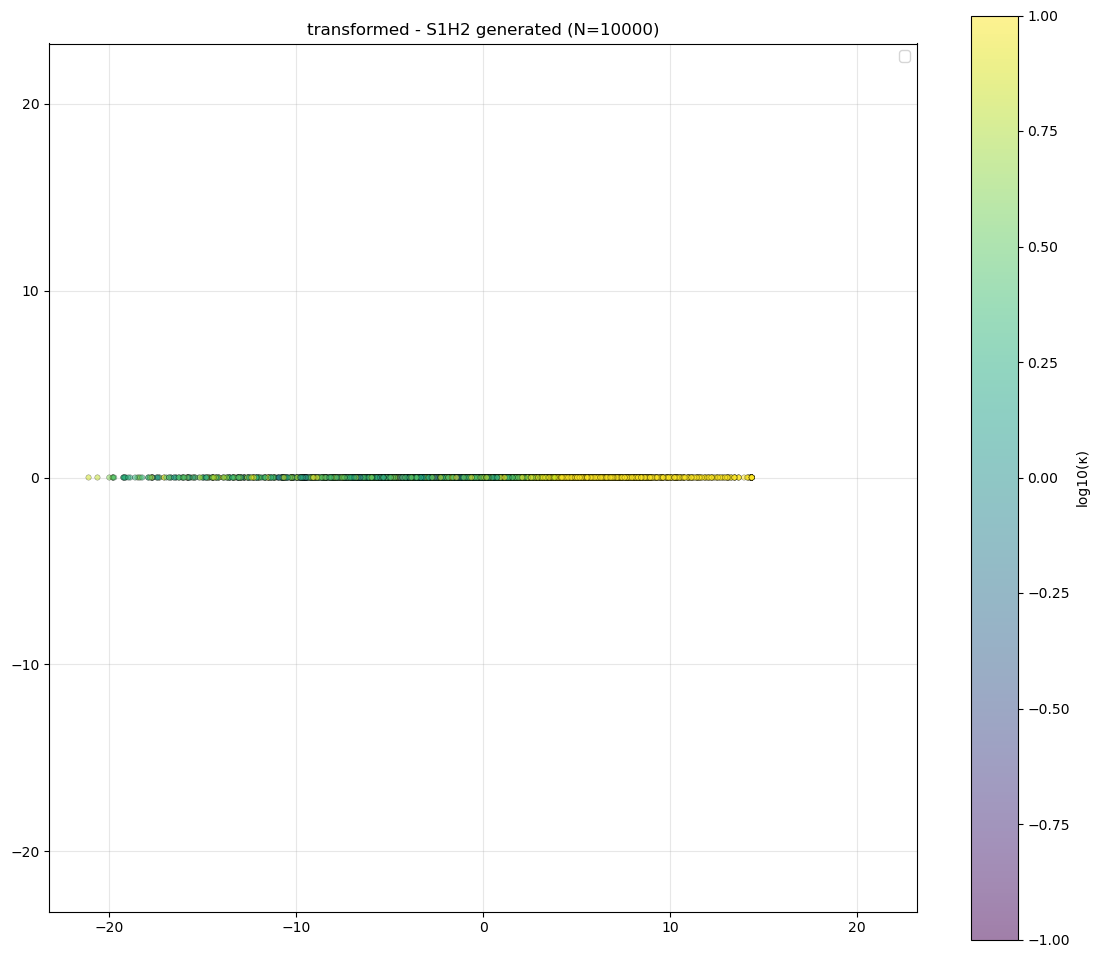

In [43]:
mercator_disc(center_node(df, '996', params), title='transformed - S1H2 generated (N=10000)')


In [19]:
max_key = max(dict(G.degree()).items(), key=lambda x: x[1])[0]
display(max_key)

'996'

### Epidèmia

In [4]:
params

{'Elapsed CPU time': '3864.55 seconds',
 'Edgelist file': './pipeline-output-s1h2/n10000.edge',
 'nb. vertices': 9979.0,
 'beta': 3.0,
 'mu': 0.0160409,
 'radius_S1': 1588.21,
 'radius_H2': 42.2768,
 'kappa_min': 0.0114342,
 'EDGELIST_FILENAME': './pipeline-output-s1h2/n10000.edge',
 'ROOTNAME_OUTPUT': 'pipeline-output-s1h2/n10000'}

In [36]:
def epidemic_func_og(dist, R, c):
    return np.exp(-c*(dist-R))

def hyperbolic_distance_og(r_a, r_b, theta_diff, zeta=1.0):   
    cosh_val = np.cosh(zeta*r_a) * np.cosh(zeta*r_b) - \
               np.sinh(zeta*r_a) * np.sinh(zeta*r_b) * np.cos(theta_diff)
    cosh_val = np.clip(cosh_val, 1.0, None)
    return np.arccosh(cosh_val) / zeta

def link_probability_og(distance, R, c=1.0):
    """Probabilidad de enlace entre 0 y 1 (estable numéricamente)"""
    z = c * (distance - R)
    # Evitar overflow
    z = np.clip(z, -700, 700)  # exp(700) es ~10^304, cerca del límite
    return 1.0 / (1.0 + np.exp(z))

R = 2 * np.log(params['nb. vertices']/(params['mu']*np.pi*params['kappa_min']**2))

hyperbolic_distance = np.vectorize(hyperbolic_distance_og, excluded={3, 'zeta'})
epidemic_func = np.vectorize(epidemic_func_og, excluded={1, 'R', 2, 'c'})
link_probability = np.vectorize(link_probability_og, excluded={1, 'R', 2, 'c'})

edges = pd.DataFrame(G.edges, columns=['a', 'b'])
edges = pd.merge(edges, df[['Vertex', 'Disc.Radius', 'Inf.Theta']], left_on='a', right_on='Vertex', suffixes=('_a', '_b'))
edges = pd.merge(edges, df[['Vertex', 'Disc.Radius', 'Inf.Theta']], left_on='b', right_on='Vertex', suffixes=('_a', '_b'))
edges['Theta_Dif'] = np.pi - np.abs(np.pi - np.abs(edges['Inf.Theta_a']-edges['Inf.Theta_b']))

edges['Distance'] = np.where(edges['Theta_Dif'] == 0, 
                            np.abs(edges['Disc.Radius_a']- edges['Disc.Radius_b']), 
                            hyperbolic_distance(edges['Disc.Radius_a'], edges['Disc.Radius_b'], edges['Theta_Dif']))
for i in (1, 2, 4, 8, 16, 32):
    c = params['beta']/i

    edges['Epidemic_Func'] = link_probability(edges['Distance'], R, c)

    avg_epidemic_func = np.average(edges['Epidemic_Func'])
    display('average', avg_epidemic_func)

    edges['Weight_Multiplier'] = edges['Epidemic_Func']/avg_epidemic_func
    edges.to_csv(f"{edges_file}_weight_{i}", sep='\t', header=False, index=False, columns=['a', 'b', 'Weight_Multiplier'])

'average'

np.float64(0.774648702555311)

'average'

np.float64(0.7533497187617222)

'average'

...

np.float64(0.6472850647134664)

'average'

np.float64(0.5882176459471568)

'average'

np.float64(0.5473855563872263)

In [26]:
output_batch_file = "./pipeline-output-s1h2/out-n10000/batch_sir_evolution.txt"

i_sim_values = reversed(range(1, 101))      # 1..100
j_sim_values = range(1, 11)       # 1..60

recovery_rate = 1.0
limit_time = 10.0
model_type = 2   # SIR_MODEL

with open(output_batch_file, "w") as f:
    f.write("# infection_rate  recovery_rate  seed  limit_time  model_type\n")
    for i in i_sim_values:
        infection_rate = i * 2 / 100.0   # real(i_sim*2, dp)/100
        for j in j_sim_values:
            seed = 42069 + j
            # Escribir línea con 5 valores (start_node opcional omitido)
            f.write(f"{infection_rate:.6f} {recovery_rate:.1f} {seed} {limit_time:.1f} {model_type}\n")

print(f"Archivo batch generado: {output_batch_file} con {100*60} simulaciones.")

Archivo batch generado: ./pipeline-output-s1h2/out-n10000/batch_sir_evolution.txt con 6000 simulaciones.


In [54]:
max_key = max(dict(G.degree()).items(), key=lambda x: x[1])[0]
display(max_key)

folder = './pipeline-output-s1h2/out-n10000/w_beta1'

! rm -rf {folder}
! mkdir {folder}
! ./tools/epidemics -b ./pipeline-output-s1h2/out-n10000/batch_sir_evolution.txt -o {folder} -st -w -sn {max_key} ./pipeline-output-s1h2/out-n10000/n10000.edge_weight_1 


'996'

 === Configuración de la simulación ===
 Archivo de red: ./pipeline-output-s1h2/out-n10000/n10000.edge_weight_1
 Nombre de red: n10000
 Modelo: SIS
 Infection rate:    1.3893526076708899E-309
 Recovery rate:    1.3893526082721085E-309
 Limit time:    50.000000000000000     
 Carpeta de output: ./pipeline-output-s1h2/out-n10000/w_beta1
 Nodo inicial:          996
 Seed:     51837773
 Weighted:  T
 Guardar stats:  T
 Guardar events:  F
 Initialized hash map
 Initialized degrees and pointers
 Initialized neighbour array
 Cleaned neighbours. Reduced neighbours by            0
 --- stats ---
N     =     9979
E     =   165444
<k>   =       33.15843271
<k^2> =    40016.22186592
Var k =      197.27326278
Var w =        1.25891774
 Ejecutando         1000  simulaciones en paralelo con OpenMP.
Filename will be n10000-wSIR-I=   2.00000-R=   1.00000-S=42075
Filename will be n10000-wSIR-I=   2.00000-R=   1.00000-S=42071
Filename will be n10000-wSIR-I=   2.00000-R=   1.00000-S=42073
Filename will be

In [49]:
dfs_weights = {}


In [55]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from multiprocessing import Pool
import functools
# LIMIT = 0.000
LIMIT = 0.000


def process_rate(rate):
    """Procesa todas las repeticiones para una tasa específica"""
    integrals = []
    outbreak_size = []
    
    for j in range(1, 11):
        filename = f"./pipeline-output-s1h2/out-n10000/w_beta1/stats-n10000-wSIR-I=   {rate:.5f}-R=   1.00000-S={42069+j}.dat"
        df = pd.read_csv(filename, sep=r'\s+', header=None, 
                        names=['t', 'idens', 'rdens', 'irate', 'rrate', ], 
                        engine='python', comment='#')
        df['sdens'] = 1 - df['rdens'] - df['idens']
        if (df['idens'].max() > LIMIT):
            integrals.append(np.trapezoid(df['idens'], df['t']))
        if (df['rdens'].iloc[-1] > LIMIT):
            outbreak_size.append(df['rdens'].iloc[-1])
    
    if (len(integrals) == 0):
        integrals = [0]
    if (len(outbreak_size) == 0):
        outbreak_size = [0]
    
    return {
        "rate": rate,
        "integral": np.mean(integrals),
        "err_integral": np.std(integrals),
        "outbreak_size": np.mean(outbreak_size),
        "err_outbreak_size": np.mean(outbreak_size)
    }

# Paralelización simple
if __name__ == "__main__":
    iters = range(2, 200+1, 2)

    with Pool() as pool:
        results = list(tqdm(pool.imap(process_rate, np.multiply(iters, 0.01)), 
                           total=len(iters)))
        # results2 = list(tqdm(pool.imap(process_rate, np.multiply(iters, 0.001)), 
        #                    total=len(iters)))
    # dfs = pd.merge(pd.DataFrame(results), pd.DataFrame(results2), how='outer')
    #     results2 = list(tqdm(pool.imap(process_rate, np.multiply(iters, 0.001)), 
    #                        total=len(iters)))
    dfs_weights['weighted_beta1'] = pd.DataFrame(results)


100%|██████████| 100/100 [00:16<00:00,  6.11it/s]


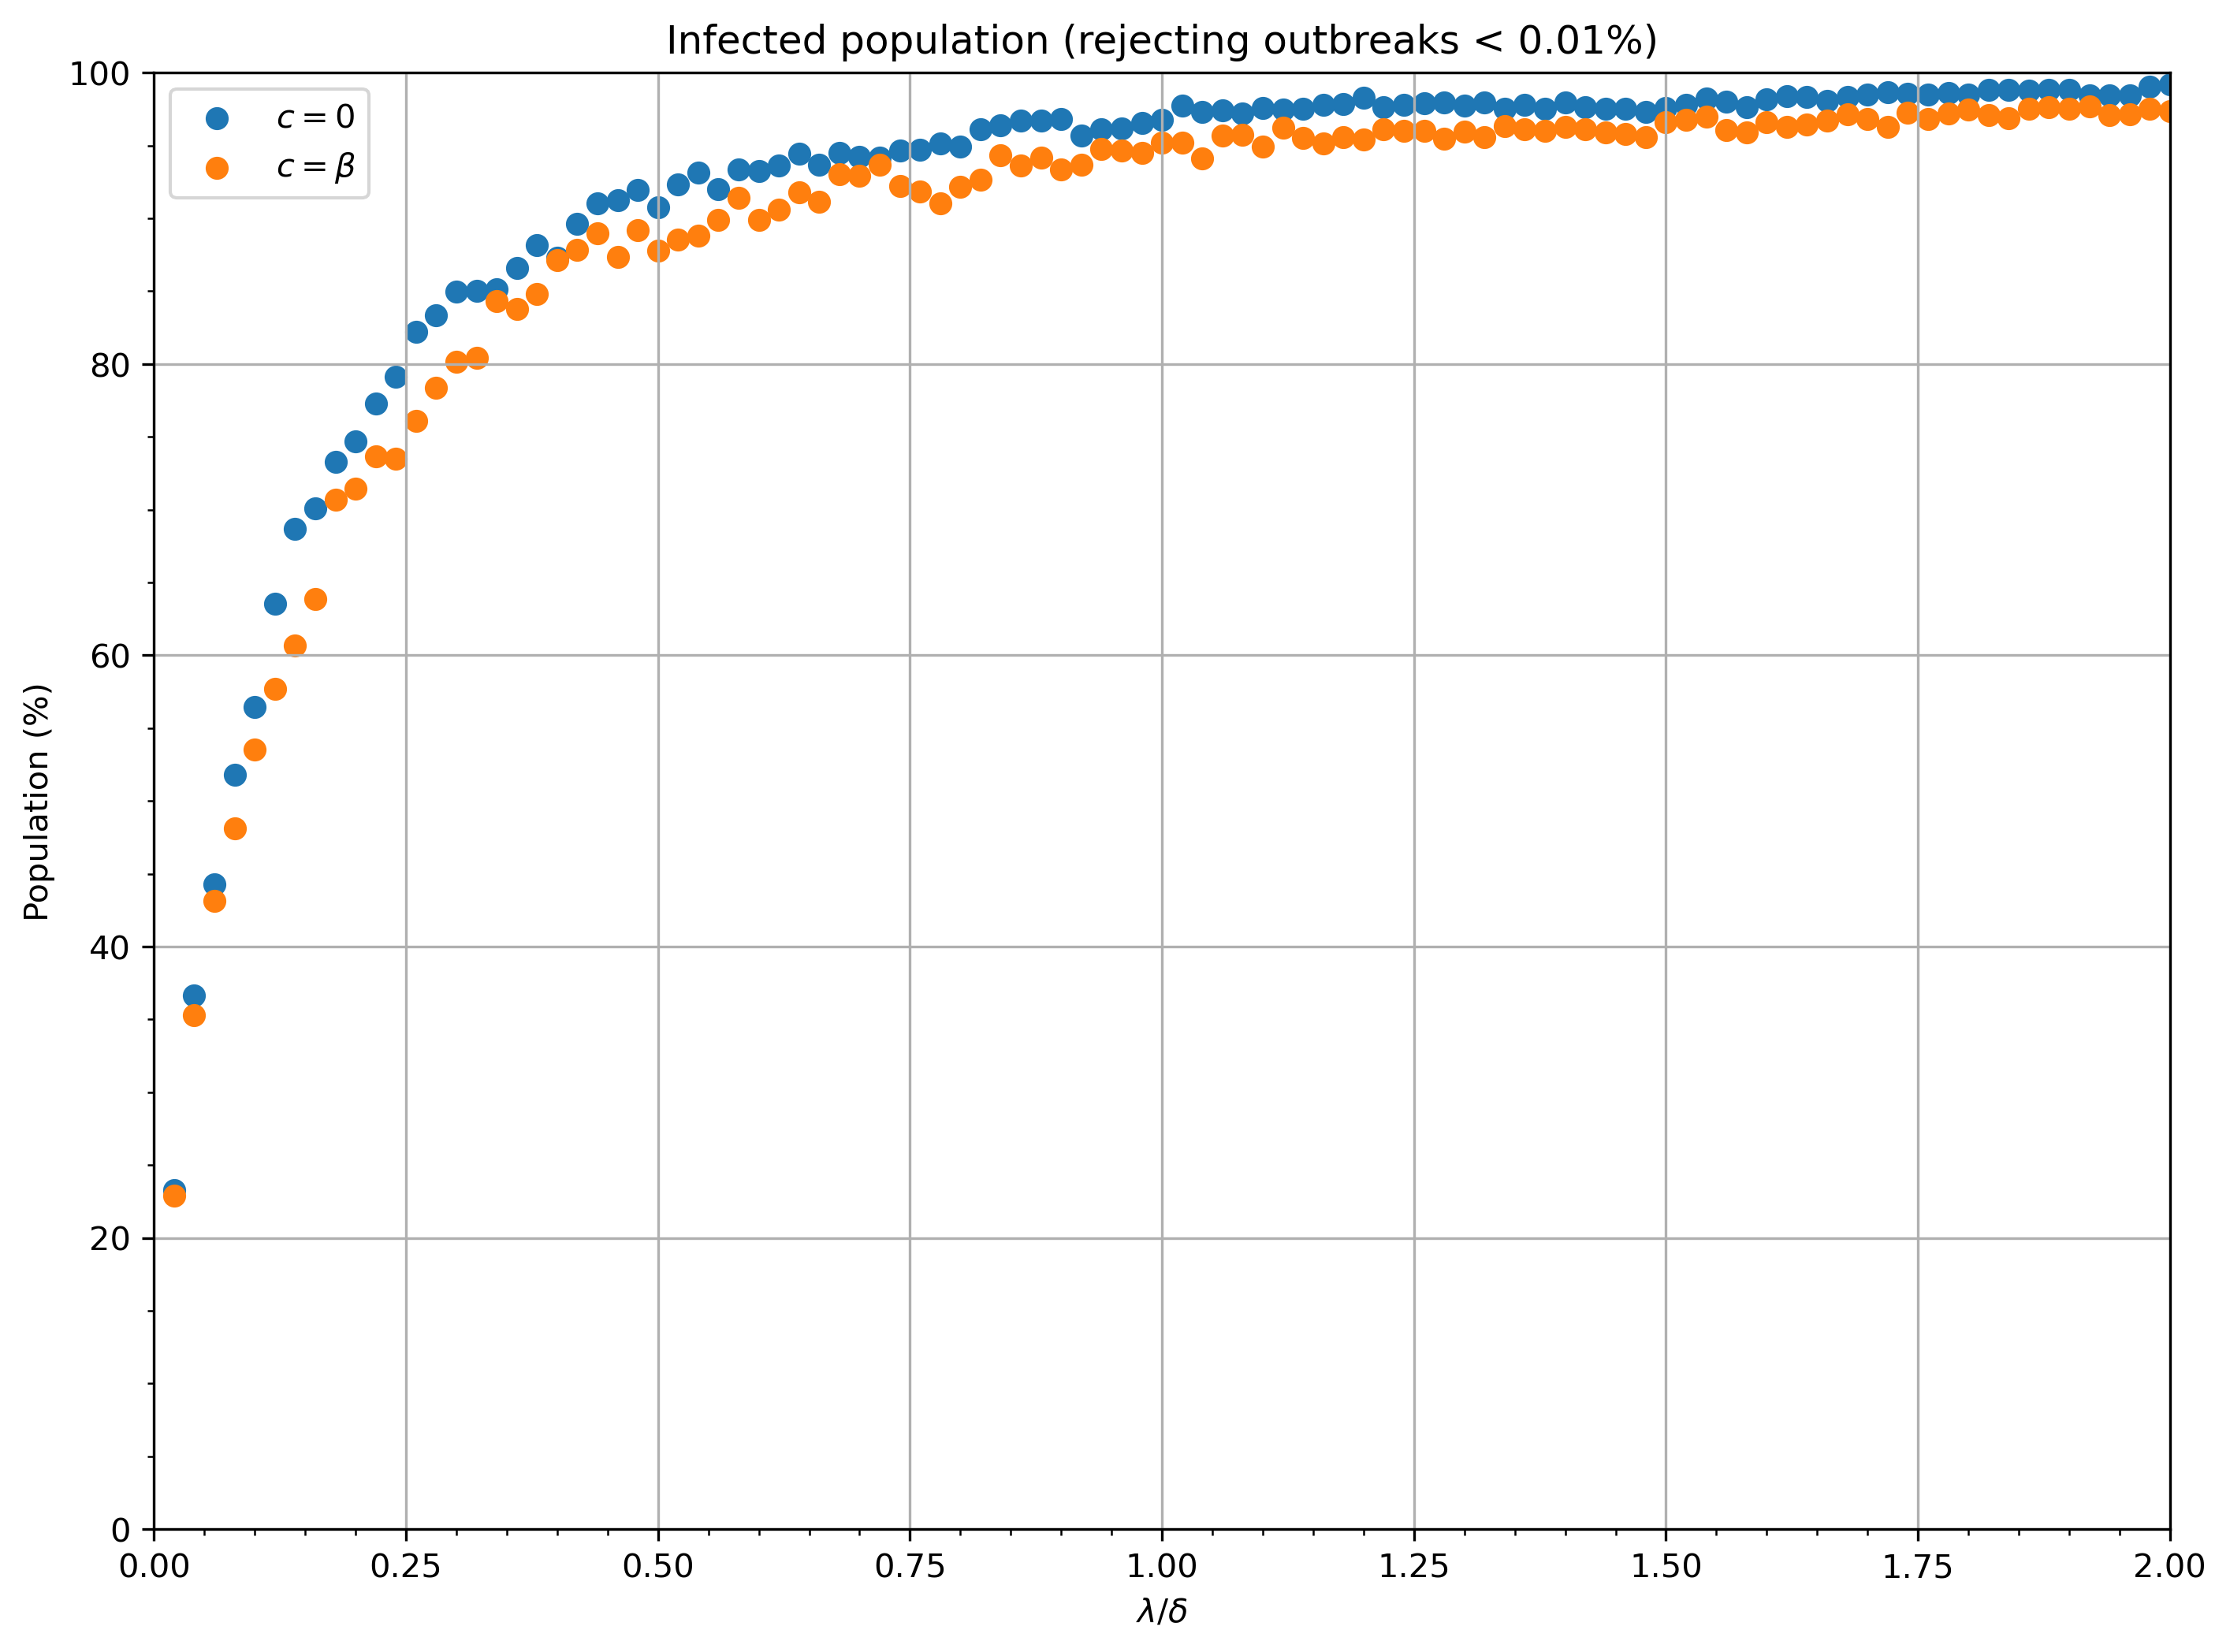

In [57]:
# set_gnuplot_style()
fig, ax = plt.subplots(figsize=(11, 8), dpi=300)
ax.minorticks_on()
ax.scatter(dfs_weights['unweighted']['rate'], dfs_weights['unweighted']['outbreak_size'], marker='o', label='$c=0$')
ax.scatter(dfs_weights['weighted_beta1']['rate'], dfs_weights['weighted_beta1']['outbreak_size'], marker='o', label=r'$c=\beta$')
# ax.errorbar(dfs['rate'], dfs['integral'], yerr=dfs['err_integral'], marker='o', linestyle='none')
# ax.scatter(df_data['x'], df_data['y'], marker='o')
ax.set_xlabel(r'$\lambda/\delta$')
ax.set_ylim(0, 1)
ax.set_yticks([i*0.2 for i in range(6)])
ax.set_yticklabels([str(i*20) for i in range(6)])
ax.set_xlim(0, 2)
# ax.legend("Outbreak")
# ax.set_ylim(0)
ax.set_title("Infected population (rejecting outbreaks < 0.01%)")
ax.set_ylabel('Population (%)')
ax.legend()
ax.grid()
plt.show()

0.5
0.5
0.5
0.49999999999999994
0.5
0.49999999999999994


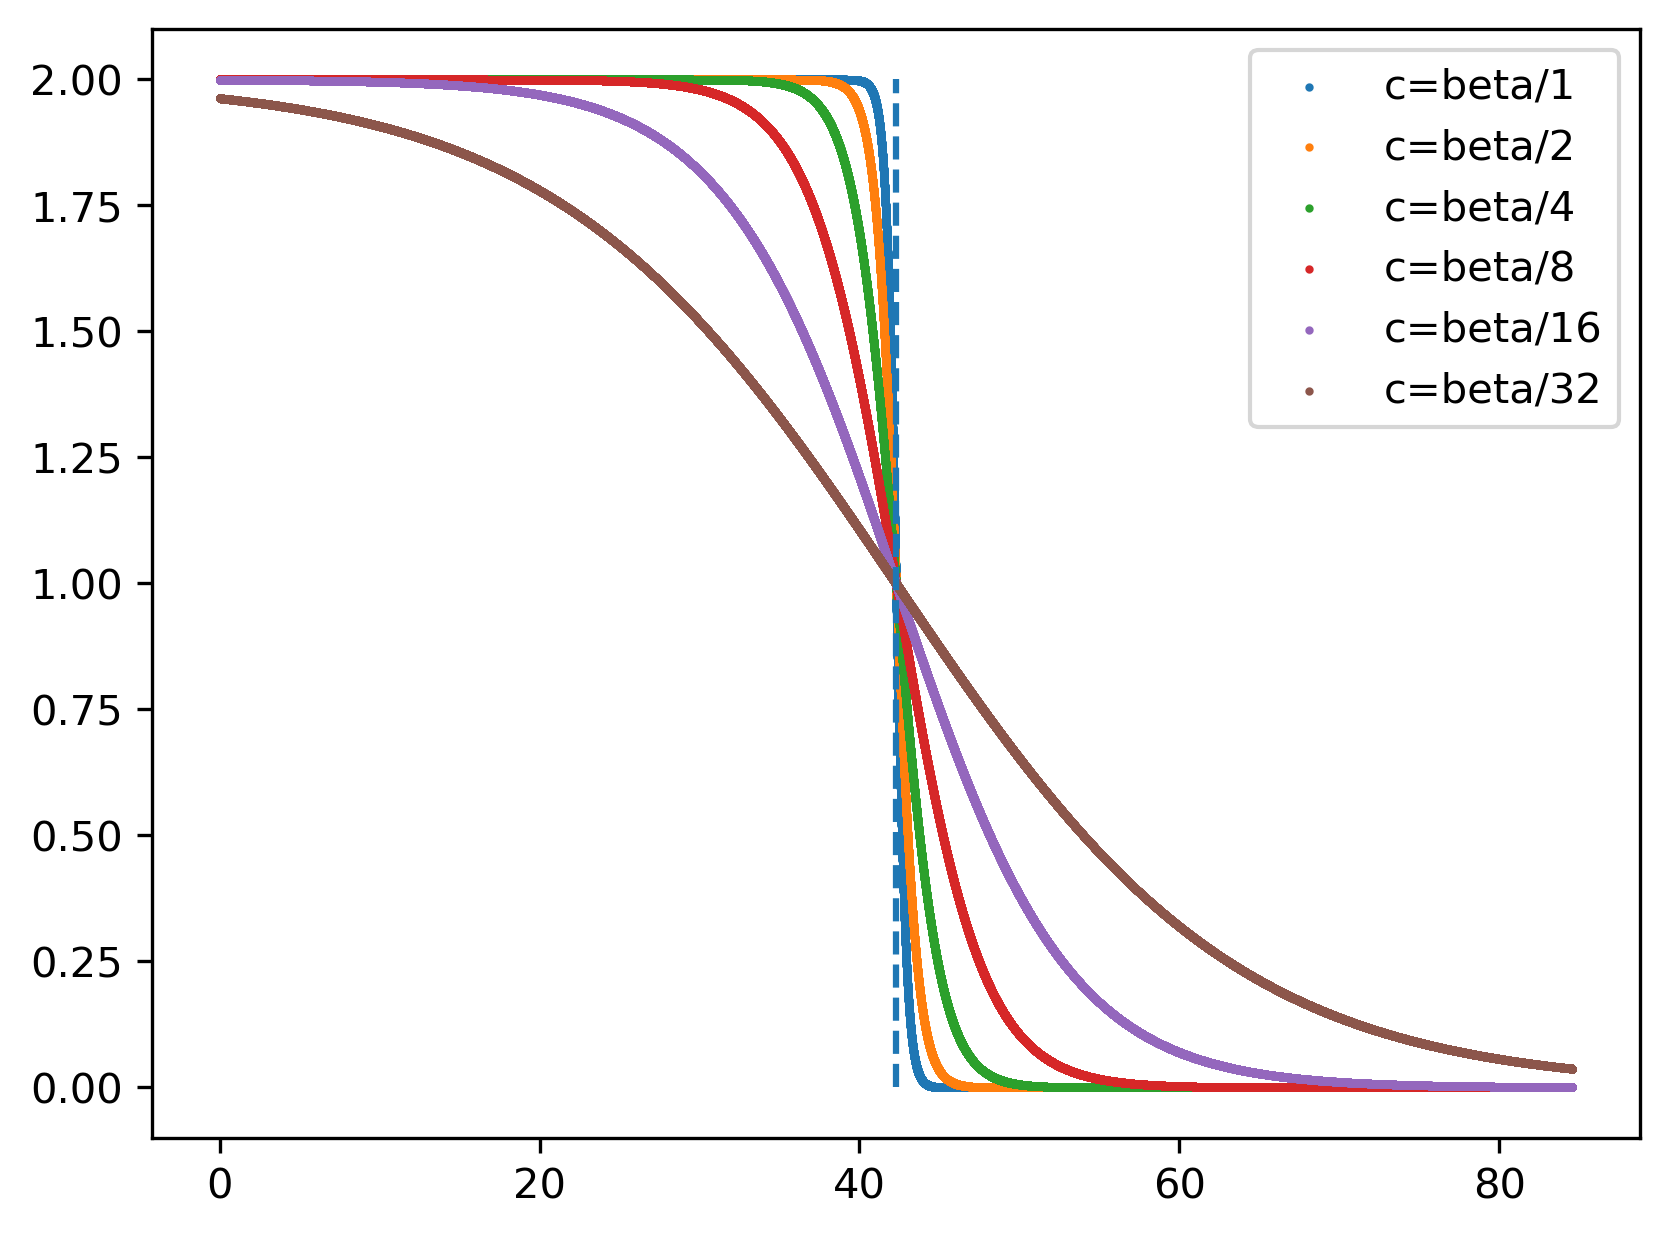

In [ ]:
fig, ax = plt.subplots(dpi=300)
R = 2 * np.log(params['nb. vertices']/(params['mu']*np.pi*params['kappa_min']**2))

xs = np.linspace(0, 2*R, 100000)

for i in (1, 2, 4, 8, 16, 32):
    prob = link_probability(xs, R, params['beta']/i)
    avprob = np.average(prob)
    print(avprob)
    ax.scatter(xs, prob/avprob, s=1, label=f'c=beta/{i}')
ax.vlines([R], 0, 2, linestyles='--')
ax.legend()
plt.show()


In [ ]:
events_file = './pipeline-output-s1h2/events-n10000-wSIR-I=  10.00000-R=   1.00000-S=*****.dat'
stats_file = './pipeline-output-s1h2/stats-n10000-wSIR-I=  10.00000-R=   1.00000-S=*****.dat'

def skip_comments(line_index, line):
    # Saltar si la línea empieza con '#' o ' #'
    return line.strip().startswith('#') or line.lstrip().startswith('#')

with open(events_file, 'r') as f:
        lines = f.readlines()
    
    # Encontrar la primera línea de datos
first_data_line = 0
for step, line in enumerate(lines):
    if not line.lstrip().startswith('#'):
        first_data_line = step
        break
events = pd.read_csv(events_file, 
                        sep='\\s+', skiprows=first_data_line, names=['t', 'vertex', 'event'])
events['vertex'] = events['vertex'].astype(str)

with open(stats_file, 'r') as f:
        lines = f.readlines()
    
    # Encontrar la primera línea de datos
first_data_line = 0
for step, line in enumerate(lines):
    if not line.lstrip().startswith('#'):
        first_data_line = step
        break

stats = pd.read_csv(stats_file, 
                        sep='\\s+', skiprows=first_data_line, names=['time', 'infected_density', 'recovered_density', 'actual_infection_rate', 'actual_recovery_rate'])

stats

,time,infected_density,recovered_density,actual_infection_rate,actual_recovery_rate
0,0.001456,0.000200,0.000000,1.854329e+03,1.0
1,0.001698,0.000301,0.000000,1.917692e+03,2.0
2,0.002068,0.000401,0.000000,1.918455e+03,3.0
3,0.002904,0.000501,0.000000,1.919253e+03,4.0
4,0.003332,0.000601,0.000000,1.919184e+03,5.0
...,...,...,...,...,...
14829,8.822521,0.000301,0.742960,-3.878334e-10,4.0
14830,8.910796,0.000200,0.743060,-3.878334e-10,3.0
14831,9.882028,0.000100,0.743161,-3.878334e-10,2.0
14832,9.885704,0.000000,0.743261,-3.878334e-10,1.0


#### Disc

In [ ]:
import math
import pandas as pd
import numpy as np
from tqdm import tqdm

def mercator_disc_epidemic_anim(df, events, epidemics_fig_output, step=0.1):
    """
    Versión optimizada que usa conjuntos de coordenadas en lugar de diccionario de estados.
    
    Parámetros:
    -----------
    df : DataFrame
        DataFrame con columnas 'Vertex', 'Disc.Radius' y coordenadas de los nodos
    events : DataFrame
        DataFrame con columnas 't', 'vertex', 'event'
    epidemics_fig_output : str
        Directorio de salida para las figuras
    step : float
        Paso de tiempo para la simulación
    """
    
    import os
    import shutil
    
    # Limpiar y crear directorio de salida
    if os.path.exists(epidemics_fig_output):
        shutil.rmtree(epidemics_fig_output)
    os.makedirs(epidemics_fig_output)
    
    # Pre-calculamos todas las coordenadas de los vértices en un diccionario
    # Asumimos que df tiene columnas 'x' e 'y' con las coordenadas
    vertex_coords = df.set_index('Vertex')[['Disc.X', 'Disc.Y']].to_dict('index')
    
    # Inicializamos conjuntos para cada estado (mucho más eficiente que diccionario)
    infected_coords = set()      # Coordenadas de infectados
    recovered_coords = set()     # Coordenadas de recuperados
    susceptible_coords = set()   # Coordenadas de susceptibles
    
    # Inicialmente todos son susceptibles
    for vertex in df['Vertex']:
        coords = (vertex_coords[vertex]['Disc.X'], vertex_coords[vertex]['Disc.Y'])
        susceptible_coords.add(coords)
    
    # Configurar tiempos
    min_time = events['t'].min()
    max_time = events['t'].max()
    print(f"Time window is {min_time:.2f} -> {max_time:.2f}")
    
    steps = math.ceil((max_time - min_time) / step)
    print(f"Total steps: {steps}")
    
    # Ordenar eventos por tiempo para búsqueda más eficiente
    events_sorted = events.sort_values('t').reset_index(drop=True)
    current_event_idx = 0
    n_events = len(events_sorted)
    
    # Bucle principal
    for i in tqdm(range(steps)):
        t = min_time + (i + 1) * step
        t_old = t - step
        
        # Procesar eventos en este intervalo de tiempo
        while (current_event_idx < n_events and 
               events_sorted.loc[current_event_idx, 't'] < t):
            
            event = events_sorted.loc[current_event_idx]
            vertex = event['vertex']
            event_type = event['event']
            
            # Obtener coordenadas del vértice
            coords = (vertex_coords[vertex]['Disc.X'], vertex_coords[vertex]['Disc.Y'])
            
            # Actualizar conjuntos según el evento
            if event_type == 'I':  # Infectado
                if coords in susceptible_coords:
                    susceptible_coords.remove(coords)
                elif coords in recovered_coords:
                    recovered_coords.remove(coords)
                infected_coords.add(coords)
                
            elif event_type == 'R':  # Recuperado
                if coords in infected_coords:
                    infected_coords.remove(coords)
                elif coords in susceptible_coords:
                    susceptible_coords.remove(coords)
                recovered_coords.add(coords)
            
            current_event_idx += 1
        
        # Generar figura con los conjuntos de coordenadas
        mercator_epidemic_disc(
            df, 
            susceptible_coords,
            infected_coords, 
            recovered_coords, 
            f'{epidemics_fig_output}/sim-{i:04d}.png', 
            t
        )

mercator_disc_epidemic_anim(df, events, 'pipeline-output-s1h2/out-n10000/disc', step=0.1)

Time window is 0.00 -> 9.89
Total steps: 99


100%|██████████| 99/99 [00:22<00:00,  4.33it/s]


In [ ]:
epidemics_fig_output = 'pipeline-output-s1h2/out-n10000/disc'
x1 = f"{epidemics_fig_output}/sim-%04d.png"
x2 = f"{epidemics_fig_output}/../disc.gif"
x3 = f"{epidemics_fig_output}/../disc-palette.png"

! ffmpeg -i {x1} -vf "palettegen" {x3} -y
! ffmpeg -i {x1} -i {x3} -filter_complex "paletteuse" {x2} -y

ffmpeg version 7.1.2 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 15 (GCC)
  configuration: --prefix=/usr --bindir=/usr/bin --datadir=/usr/share/ffmpeg --docdir=/usr/share/doc/ffmpeg --incdir=/usr/include/ffmpeg --libdir=/usr/lib64 --mandir=/usr/share/man --arch=x86_64 --optflags='-O2 -flto=auto -ffat-lto-objects -fexceptions -g -grecord-gcc-switches -pipe -Wall -Werror=format-security -Wno-error=incompatible-pointer-types -Wp,-U_FORTIFY_SOURCE,-D_FORTIFY_SOURCE=3 -Wp,-D_GLIBCXX_ASSERTIONS -specs=/usr/lib/rpm/redhat/redhat-hardened-cc1 -fstack-protector-strong -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -m64 -march=x86-64 -mtune=generic -fasynchronous-unwind-tables -fstack-clash-protection -fcf-protection -mtls-dialect=gnu2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer ' --extra-ldflags='-Wl,-z,relro -Wl,--as-needed -Wl,-z,pack-relative-relocs -Wl,-z,now -specs=/usr/lib/rpm/redhat/redhat-hardened-ld -specs=/usr/lib/rpm/redhat/redhat-hardened-ld-errors -specs=

#### Histograma

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import os

def crear_histogramas_infectados_por_radio(df, events, tiempo_objetivo=None, 
                                           bin_size=10, step_tiempo=1, max_infected = None,
                                           output_dir='histogramas'):
    """
    Crea histogramas de nodos infectados agrupados por radio.
    
    Parámetros:
    -----------
    df : DataFrame
        DataFrame con columnas 'Vertex' y 'Disc.Radius'
    events : DataFrame
        DataFrame con columnas 't', 'vertex', 'event'
    tiempo_objetivo : float, opcional
        Tiempo específico para generar un solo histograma. Si es None, genera 
        histogramas para toda la simulación
    bin_size : int
        Tamaño de los bins para agrupar los radios
    step_tiempo : float
        Paso de tiempo entre histogramas (si tiempo_objetivo es None)
    output_dir : str
        Directorio donde guardar los histogramas
    """
    import shutil
    
    # Crear directorio de salida si no existe
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.mkdir(output_dir)
    # Unir la información de los nodos con sus radios
    df_radios = df.set_index('Vertex')['Disc.Radius'].to_dict()
    if (not max_infected):
        max_infected = len(df)
    max_radius = np.max(df['Disc.Radius'])
    # Función para obtener el estado de los nodos en un tiempo dado
    def get_estado_en_tiempo(t):
        # Filtrar eventos hasta el tiempo t
        events_hasta_t = events[events['t'] <= t].copy()
        
        # Ordenar por tiempo para obtener el último evento de cada nodo
        events_hasta_t = events_hasta_t.sort_values('t')
        
        # Obtener el último estado de cada nodo
        ultimos_eventos = events_hasta_t.groupby('vertex').last()
        
        # Crear diccionario de estados
        estados = {}
        for vertex in df['Vertex']:
            if vertex in ultimos_eventos.index:
                estados[vertex] = ultimos_eventos.loc[vertex, 'event']
            else:
                estados[vertex] = 'S'  # Por defecto susceptible
        
        return estados
    
    # Función para crear un histograma en un tiempo específico
    def crear_histograma_tiempo(t, ax=None, guardar=True, step=0):
        estados = get_estado_en_tiempo(t)
        
        # Clasificar nodos por radio y estado
        radios_infectados = []
        for vertex, estado in estados.items():
            if estado == 'I':  # Solo considerar infectados
                radio = df_radios.get(vertex, 0)
                radios_infectados.append(radio)
        
        # Crear bins
        if radios_infectados:
            max_radio = max(df['Disc.Radius'])
            bins = np.arange(0, max_radio + bin_size, bin_size)
            
            if ax is None:
                fig, ax = plt.subplots(figsize=(10, 6))
            
            # Histograma
            counts, bins, patches = ax.hist(radios_infectados, bins=bins, 
                                           edgecolor='black', alpha=0.7, 
                                           color='red')
            ax.set_xlim(0, max_radius)
            ax.set_ylim(0, max_infected)
            ax.set_xlabel('Radio del disco')
            ax.set_ylabel('Número de nodos infectados')
            ax.set_title(f'Distribución de nodos infectados por radio\n(t = {t:.2f})')
            ax.grid(True, alpha=0.3)
            
            # Añadir etiquetas con los valores
            for i, (count, bin_edge) in enumerate(zip(counts, bins[:-1])):
                if count > 0:
                    ax.text(bin_edge + bin_size/2, count + 0.5, 
                           str(int(count)), ha='center', va='bottom')
            
            if guardar:
                plt.savefig(f'{output_dir}/histograma_t_{step}.png', 
                          dpi=300, bbox_inches='tight')
                plt.close()
            else:
                return ax
        else:
            print(f"Advertencia: No hay nodos infectados en t = {t:.2f}")
            return None
    
    # Caso 1: Tiempo específico
    if tiempo_objetivo is not None:
        crear_histograma_tiempo(tiempo_objetivo, guardar=True)
        print(f"Histograma creado para t = {tiempo_objetivo}")
    
    # Caso 2: Toda la simulación con step_tiempo
    else:
        # Encontrar el rango de tiempos
        t_min = events['t'].min()
        t_max = events['t'].max()
        
        # Crear array de tiempos
        tiempos = np.arange(t_min, t_max + step_tiempo, step_tiempo)
        
        print(f"Generando {len(tiempos)} histogramas...")
        for step, t in enumerate(tiempos):
            crear_histograma_tiempo(t, guardar=True, step=step)
            if (step + 1) % 10 == 0:
                print(f"Progreso: {step + 1}/{len(tiempos)} histogramas creados")
        
        print(f"¡Completado! Se crearon {len(tiempos)} histogramas en '{output_dir}'")

# Función adicional para crear un histograma combinado
def crear_histograma_combinado(df, events, tiempos_interes, bin_size=10, max_infected=None):
    """
    Crea un histograma combinado con múltiples tiempos en una misma figura.
    """
    df_radios = df.set_index('Vertex')['Disc.Radius'].to_dict()
    
    if (not max_infected):
        max_infected = len(df)
    def get_infectados_por_radio(t):
        events_hasta_t = events[events['t'] <= t].copy()
        events_hasta_t = events_hasta_t.sort_values('t')
        ultimos_eventos = events_hasta_t.groupby('vertex').last()
        
        radios_infectados = []
        for vertex in df['Vertex']:
            if vertex in ultimos_eventos.index and ultimos_eventos.loc[vertex, 'event'] == 'I':
                radios_infectados.append(df_radios.get(vertex, 0))
        
        return radios_infectados
    
    # Crear figura
    fig, axes = plt.subplots(len(tiempos_interes), 1, figsize=(12, 4*len(tiempos_interes)))
    if len(tiempos_interes) == 1:
        axes = [axes]
    
    max_radio = max(df['Disc.Radius'])
    bins = np.arange(0, max_radio + bin_size, bin_size)
    
    for ax, t in zip(axes, tiempos_interes):
        radios = get_infectados_por_radio(t)
        
        if radios:
            ax.set_xlim(0, max_radio)
            ax.set_ylim(0, max_infected)
            ax.hist(radios, bins=bins, edgecolor='black', alpha=0.7, color='red')
            ax.set_xlabel('Radio del disco')
            ax.set_ylabel('Nodos infectados')
            ax.set_title(f't = {t:.2f}')
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('histograma_combinado.png', dpi=300, bbox_inches='tight')
    plt.show()


# print("Ejemplo 1: Histograma en t=50")
# crear_histogramas_infectados_por_radio(
#     df, 
#     events, 
#     tiempo_objetivo=10,
#     bin_size=2.5
# )

# # Ejemplo 2: Histogramas para toda la simulación
print("\nEjemplo 2: Histogramas para toda la simulación")
crear_histogramas_infectados_por_radio(
    df, 
    events, 
    step_tiempo=0.1,
    # tiempo_objetivo=10,
    bin_size=1,
    output_dir='pipeline-output-s1h2/out-n10000/hist',
    max_infected=1500
)

# # Ejemplo 3: Histograma combinado
# print("\nEjemplo 3: Histograma combinado")
# crear_histograma_combinado(
#     df_ejemplo, 
#     events_ejemplo, 
#     tiempos_interes=[25, 50, 75],
#     bin_size=10
# )


Ejemplo 2: Histogramas para toda la simulación
Generando 100 histogramas...
Progreso: 10/100 histogramas creados
Progreso: 20/100 histogramas creados
Progreso: 30/100 histogramas creados
Progreso: 40/100 histogramas creados
Progreso: 50/100 histogramas creados
Progreso: 60/100 histogramas creados
Progreso: 70/100 histogramas creados
Progreso: 80/100 histogramas creados
Progreso: 90/100 histogramas creados
Advertencia: No hay nodos infectados en t = 9.90
Progreso: 100/100 histogramas creados
¡Completado! Se crearon 100 histogramas en 'pipeline-output-s1h2/out-n10000/hist'


In [44]:
x1 = f"pipeline-output-s1h2/out-n10000/hist/histograma_t_%d.png"
x2 = f"pipeline-output-s1h2/out-n10000/hist.gif"
x3 = f"pipeline-output-s1h2/out-n10000/hist-palette.png"

! ffmpeg -i {x1} -vf "palettegen" {x3} -y
! ffmpeg -i {x1} -i {x3} -filter_complex "paletteuse" {x2} -y

2091.94s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


ffmpeg version 7.1.2 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 15 (GCC)
  configuration: --prefix=/usr --bindir=/usr/bin --datadir=/usr/share/ffmpeg --docdir=/usr/share/doc/ffmpeg --incdir=/usr/include/ffmpeg --libdir=/usr/lib64 --mandir=/usr/share/man --arch=x86_64 --optflags='-O2 -flto=auto -ffat-lto-objects -fexceptions -g -grecord-gcc-switches -pipe -Wall -Werror=format-security -Wno-error=incompatible-pointer-types -Wp,-U_FORTIFY_SOURCE,-D_FORTIFY_SOURCE=3 -Wp,-D_GLIBCXX_ASSERTIONS -specs=/usr/lib/rpm/redhat/redhat-hardened-cc1 -fstack-protector-strong -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -m64 -march=x86-64 -mtune=generic -fasynchronous-unwind-tables -fstack-clash-protection -fcf-protection -mtls-dialect=gnu2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer ' --extra-ldflags='-Wl,-z,relro -Wl,--as-needed -Wl,-z,pack-relative-relocs -Wl,-z,now -specs=/usr/lib/rpm/redhat/redhat-hardened-ld -specs=/usr/lib/rpm/redhat/redhat-hardened-ld-errors -specs=

2098.92s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


ffmpeg version 7.1.2 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 15 (GCC)
  configuration: --prefix=/usr --bindir=/usr/bin --datadir=/usr/share/ffmpeg --docdir=/usr/share/doc/ffmpeg --incdir=/usr/include/ffmpeg --libdir=/usr/lib64 --mandir=/usr/share/man --arch=x86_64 --optflags='-O2 -flto=auto -ffat-lto-objects -fexceptions -g -grecord-gcc-switches -pipe -Wall -Werror=format-security -Wno-error=incompatible-pointer-types -Wp,-U_FORTIFY_SOURCE,-D_FORTIFY_SOURCE=3 -Wp,-D_GLIBCXX_ASSERTIONS -specs=/usr/lib/rpm/redhat/redhat-hardened-cc1 -fstack-protector-strong -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -m64 -march=x86-64 -mtune=generic -fasynchronous-unwind-tables -fstack-clash-protection -fcf-protection -mtls-dialect=gnu2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer ' --extra-ldflags='-Wl,-z,relro -Wl,--as-needed -Wl,-z,pack-relative-relocs -Wl,-z,now -specs=/usr/lib/rpm/redhat/redhat-hardened-ld -specs=/usr/lib/rpm/redhat/redhat-hardened-ld-errors -specs=

In [45]:
def crear_histograma_proporcion_infectados(df, events, tiempo_objetivo=None,
                                          bin_size=10, step_tiempo=1,
                                          output_dir='histogramas_proporcion'):
    """
    Crea histogramas de la PROPORCIÓN de nodos infectados en cada rango de radio.
    (Dividido por la cantidad total de nodos en cada barra)
    
    Parámetros:
    -----------
    df : DataFrame
        DataFrame con columnas 'Vertex' y 'Disc.Radius'
    events : DataFrame
        DataFrame con columnas 't', 'vertex', 'event'
    tiempo_objetivo : float, opcional
        Tiempo específico para generar un solo histograma. Si es None, genera 
        histogramas para toda la simulación
    bin_size : int
        Tamaño de los bins para agrupar los radios
    step_tiempo : float
        Paso de tiempo entre histogramas (si tiempo_objetivo es None)
    output_dir : str
        Directorio donde guardar los histogramas
    """
    import shutil
    
    # Crear directorio de salida
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.mkdir(output_dir)
    
    # Preparar datos
    df_radios = df.set_index('Vertex')['Disc.Radius'].to_dict()
    max_radius = np.max(df['Disc.Radius'])
    bins = np.arange(0, max_radius + bin_size, bin_size)
    
    # Pre-calcular la distribución de todos los nodos por radio
    todos_los_radios = list(df['Disc.Radius'])
    total_por_bin, _ = np.histogram(todos_los_radios, bins=bins)
    
    # Función para obtener el estado en un tiempo dado (optimizada)
    def get_estado_en_tiempo(t):
        events_hasta_t = events[events['t'] <= t].copy()
        if len(events_hasta_t) > 0:
            events_hasta_t = events_hasta_t.sort_values('t')
            ultimos_eventos = events_hasta_t.groupby('vertex').last()
        else:
            ultimos_eventos = pd.DataFrame()
        
        estados = {}
        for vertex in df['Vertex']:
            if vertex in ultimos_eventos.index:
                estados[vertex] = ultimos_eventos.loc[vertex, 'event']
            else:
                estados[vertex] = 'S'
        return estados
    
    # Función para crear el histograma de proporciones
    def crear_histograma_proporcion(t, guardar=True, step=0):
        estados = get_estado_en_tiempo(t)
        
        # Obtener radios de infectados
        radios_infectados = []
        for vertex, estado in estados.items():
            if estado == 'I':
                radios_infectados.append(df_radios.get(vertex, 0))
        
        # Crear figura
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Histograma 1: Números absolutos (lado izquierdo)
        if radios_infectados:
            counts_abs, _, patches_abs = ax1.hist(radios_infectados, bins=bins,
                                                 edgecolor='black', alpha=0.7,
                                                 color='red', rwidth=0.8)
            ax1.set_ylim(0, max(total_por_bin) * 1.1)
            
            # Añadir etiquetas
            for i, (count, bin_edge) in enumerate(zip(counts_abs, bins[:-1])):
                if count > 0:
                    ax1.text(bin_edge + bin_size/2, count + 0.5,
                            str(int(count)), ha='center', va='bottom', fontsize=8)
        else:
            ax1.hist([], bins=bins, edgecolor='black', alpha=0.7, color='red', rwidth=0.8)
        
        ax1.set_xlim(0, max_radius)
        ax1.set_xlabel('Radio del disco')
        ax1.set_ylabel('Número de nodos infectados')
        ax1.set_title(f'Nº Absoluto de Infectados\n(t = {t:.2f})')
        ax1.grid(True, alpha=0.3)
        ax1.set_xticks(bins[::2])  # Mostrar cada 2 ticks para no saturar
        
        # Histograma 2: Proporción (lado derecho) - ¡ESTE ES EL NUEVO!
        if radios_infectados:
            counts_prop, _, patches_prop = ax2.hist(radios_infectados, bins=bins,
                                                    edgecolor='black', alpha=0.7,
                                                    color='blue', rwidth=0.8,
                                                    weights=np.ones_like(radios_infectados) / len(radios_infectados))
            
            # Calcular proporción sobre total de nodos en cada bin
            proporcion_por_bin = []
            for i, (count, total) in enumerate(zip(counts_abs, total_por_bin)):
                if total > 0:
                    prop = count / total
                    proporcion_por_bin.append(prop)
                else:
                    proporcion_por_bin.append(0)
                    prop = 0
                
                # Añadir etiqueta con la proporción y el total
                if count > 0:
                    ax2.text(bins[i] + bin_size/2, prop + 0.02,
                            f'{prop:.1%}\n({int(count)}/{int(total)})',
                            ha='center', va='bottom', fontsize=8,
                            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
            
            # Dibujar barras de proporción
            ax2.cla()  # Limpiar el histograma anterior
            bars = ax2.bar(bins[:-1], proporcion_por_bin, width=bin_size*0.8,
                          align='edge', edgecolor='black', alpha=0.7,
                          color='blue')
            
            # Colorear las barras según el valor
            for bar, prop in zip(bars, proporcion_por_bin):
                bar.set_color(plt.cm.RdYlGn(prop))  # Rojo=0%, Verde=100%
        else:
            ax2.bar(bins[:-1], np.zeros(len(bins)-1), width=bin_size*0.8,
                   align='edge', edgecolor='black', alpha=0.7, color='lightgray')
            ax2.text(max_radius/2, 0.5, 'Sin infectados',
                    ha='center', va='center', fontsize=12, color='gray')
        
        ax2.set_xlim(0, max_radius)
        ax2.set_ylim(0, 1.1)  # La proporción siempre entre 0 y 1
        ax2.set_xlabel('Radio del disco')
        ax2.set_ylabel('Proporción de nodos infectados')
        ax2.set_title(f'Proporción de Infectados por Radio\n(t = {t:.2f})')
        ax2.grid(True, alpha=0.3)
        ax2.set_xticks(bins[::2])
        ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)  # Línea del 50%
        
        # Añadir información total
        total_infectados = len(radios_infectados)
        fig.suptitle(f'Análisis de Infectados por Radio - Total: {total_infectados} infectados',
                    fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        
        if guardar:
            plt.savefig(f'{output_dir}/proporcion_t_{step:04d}.png',
                       dpi=300, bbox_inches='tight')
            plt.close()
        else:
            return fig, (ax1, ax2)
    
    # Generar histogramas
    if tiempo_objetivo is not None:
        crear_histograma_proporcion(tiempo_objetivo, guardar=True)
        print(f"Histograma de proporción creado para t = {tiempo_objetivo}")
    else:
        t_min = events['t'].min()
        t_max = events['t'].max()
        tiempos = np.arange(t_min, t_max + step_tiempo, step_tiempo)
        
        print(f"Generando {len(tiempos)} histogramas de proporción...")
        for step, t in enumerate(tiempos):
            crear_histograma_proporcion(t, guardar=True, step=step)
            if (step + 1) % 10 == 0:
                print(f"Progreso: {step + 1}/{len(tiempos)}")
        
        print(f"¡Completado! Histogramas guardados en '{output_dir}'")

# Función adicional: Solo proporción (versión simplificada)
def crear_grafico_barras_proporcion(df, events, tiempo_objetivo=None,
                                   bin_size=10, step_tiempo=1,
                                   output_dir='barras_proporcion'):
    """
    Versión simplificada que SOLO muestra las barras de proporción.
    """
    import shutil
    
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.mkdir(output_dir)
    
    df_radios = df.set_index('Vertex')['Disc.Radius'].to_dict()
    max_radius = np.max(df['Disc.Radius'])
    bins = np.arange(0, max_radius + bin_size, bin_size)
    
    # Pre-calcular distribución total
    todos_los_radios = list(df['Disc.Radius'])
    total_por_bin, _ = np.histogram(todos_los_radios, bins=bins)
    
    def crear_barras_proporcion(t, guardar=True, step=0):
        events_hasta_t = events[events['t'] <= t].copy()
        if len(events_hasta_t) > 0:
            events_hasta_t = events_hasta_t.sort_values('t')
            ultimos_eventos = events_hasta_t.groupby('vertex').last()
        else:
            ultimos_eventos = pd.DataFrame()
        
        # Contar infectados por bin
        infectados_por_bin = np.zeros(len(bins)-1)
        for vertex in df['Vertex']:
            if vertex in ultimos_eventos.index and ultimos_eventos.loc[vertex, 'event'] == 'I':
                radio = df_radios.get(vertex, 0)
                bin_idx = np.digitize(radio, bins) - 1
                if 0 <= bin_idx < len(infectados_por_bin):
                    infectados_por_bin[bin_idx] += 1
        
        # Calcular proporción
        proporcion = np.divide(infectados_por_bin, total_por_bin,
                              out=np.zeros_like(infectados_por_bin),
                              where=total_por_bin!=0)
        
        # Crear gráfico de barras
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Barras coloreadas por proporción
        bars = ax.bar(bins[:-1], proporcion, width=bin_size*0.8,
                     align='edge', edgecolor='black', alpha=0.7)
        
        # Colorear barras
        for bar, prop in zip(bars, proporcion):
            bar.set_color(plt.cm.RdYlGn(prop))
            
        # Añadir etiquetas
        for i, (prop, total_inf, total) in enumerate(zip(proporcion, infectados_por_bin, total_por_bin)):
            if total > 0:
                ax.text(bins[i] + bin_size/2, prop + 0.02,
                       f'{prop:.1%}\n({int(total_inf)}/{int(total)})',
                       ha='center', va='bottom', fontsize=9,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        ax.set_xlim(0, max_radius)
        ax.set_ylim(0, 1.1)
        ax.set_xlabel('Radio del disco')
        ax.set_ylabel('Proporción de nodos infectados')
        ax.set_title(f'Proporción de Infectados por Radio (t = {t:.2f})\nTotal infectados: {int(sum(infectados_por_bin))}')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xticks(bins[::2])
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        
        if guardar:
            plt.savefig(f'{output_dir}/barras_t_{step:04d}.png',
                       dpi=300, bbox_inches='tight')
            plt.close()
        else:
            return fig, ax
    
    # Generar gráficos
    if tiempo_objetivo is not None:
        crear_barras_proporcion(tiempo_objetivo, guardar=True)
    else:
        t_min = events['t'].min()
        t_max = events['t'].max()
        tiempos = np.arange(t_min, t_max + step_tiempo, step_tiempo)
        
        print(f"Generando {len(tiempos)} gráficos de barras...")
        for step, t in enumerate(tiempos):
            crear_barras_proporcion(t, guardar=True, step=step)
        
        print(f"¡Completado! Gráficos guardados en '{output_dir}'")

# Ejemplo de uso con tus datos
print("\nGenerando gráficos de PROPORCIÓN de infectados...")
crear_histograma_proporcion_infectados(
    df=df,
    events=events,
    step_tiempo=0.1,
    bin_size=1,
    output_dir='pipeline-output-s1h2/out-n10000/hist_proporcion'
)


# # O usar la versión simplificada de solo barras
# print("\nGenerando gráficos de BARRAS de proporción...")
# crear_grafico_barras_proporcion(
#     df=df,
#     events=events,
#     step_tiempo=0.1,
#     bin_size=1,
#     output_dir='pipeline-output-s1h2/out-n10000/barras_proporcion'
# )


Generando gráficos de PROPORCIÓN de infectados...
Generando 100 histogramas de proporción...
Progreso: 10/100
Progreso: 20/100
Progreso: 30/100
Progreso: 40/100
Progreso: 50/100
Progreso: 60/100
Progreso: 70/100
Progreso: 80/100
Progreso: 90/100
Progreso: 100/100
¡Completado! Histogramas guardados en 'pipeline-output-s1h2/out-n10000/hist_proporcion'


In [ ]:
x1 = f"pipeline-output-s1h2/out-n10000/hist_proporcion/proporcion_t_%04d.png"
x2 = f"pipeline-output-s1h2/out-n10000/hist_proporcion.gif"
x3 = f"pipeline-output-s1h2/out-n10000/hist_proporcion-palette.png"

! ffmpeg -i {x1} -vf "palettegen" {x3} -y
! ffmpeg -i {x1} -i {x3} -filter_complex "paletteuse" {x2} -y